In [1]:
print("Hello, Subway Network Project!")

Hello, Subway Network Project!


In [4]:
sorted_df["State"].unique()

array(['New York', 'California', 'Illinois', 'Texas', 'Pennsylvania',
       'Arizona', 'Indiana', 'Florida', 'Ohio', 'North Carolina',
       'Michigan', 'Tennessee', 'Washington', 'Colorado',
       'District of Columbia', 'Massachusetts', 'Maryland', 'Oklahoma',
       'Kentucky', 'Oregon', 'Nevada', 'Wisconsin', 'New Mexico',
       'Missouri', 'Virginia', 'Georgia', 'Nebraska', 'Minnesota',
       'Kansas', 'Louisiana', 'Hawaii', 'Alaska', 'New Jersey', 'Idaho',
       'Alabama', 'Iowa', 'Arkansas', 'Utah', 'Rhode Island',
       'Mississippi', 'South Dakota', 'Connecticut', 'South Carolina',
       'North Dakota', 'New Hampshire', 'Montana', 'Delaware', 'Maine',
       'Wyoming', 'West Virginia', 'Vermont'], dtype=object)

In [5]:
ak_hi_df = sorted_df[sorted_df["State"].isin(["Alaska", "Hawaii"])]
print(ak_hi_df[["City", "State", "Population"]].head())

          City   State  Population
785   Honolulu  Hawaii      347884
370  Anchorage  Alaska      300950


In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/plotly/datasets/master/us-cities-top-1k.csv"
full_df = pd.read_csv(url)

sorted_df = full_df.sort_values(by="Population", ascending=False)

def build_top_100_graph(df):
    G = nx.Graph()

    top_100_df = df.head(100)

    for i, row in top_100_df.iterrows():
        G.add_node(
            row["City"],
            pos=(row["lon"], row["lat"]),
            population=row["Population"]
        )

    return G

top_100_graph = build_top_100_graph(sorted_df)

print("Nodes:", top_100_graph.number_of_nodes())
print("Edges:", top_100_graph.number_of_edges())


def build_state_graph(df):
    G = nx.Graph()

    state_representatives = df.sort_values("Population", ascending=False).drop_duplicates("State")

    for i, row in state_representatives.iterrows():
        G.add_node(
            row["State"],
            pos=(row["lon"], row["lat"]),
            city=row["City"],
            population=row["Population"]
        )

    return G

state_graph = build_state_graph(sorted_df)

print("State Nodes:", state_graph.number_of_nodes())
print("State Edges:", state_graph.number_of_edges())

Nodes: 100
Edges: 0
State Nodes: 51
State Edges: 0


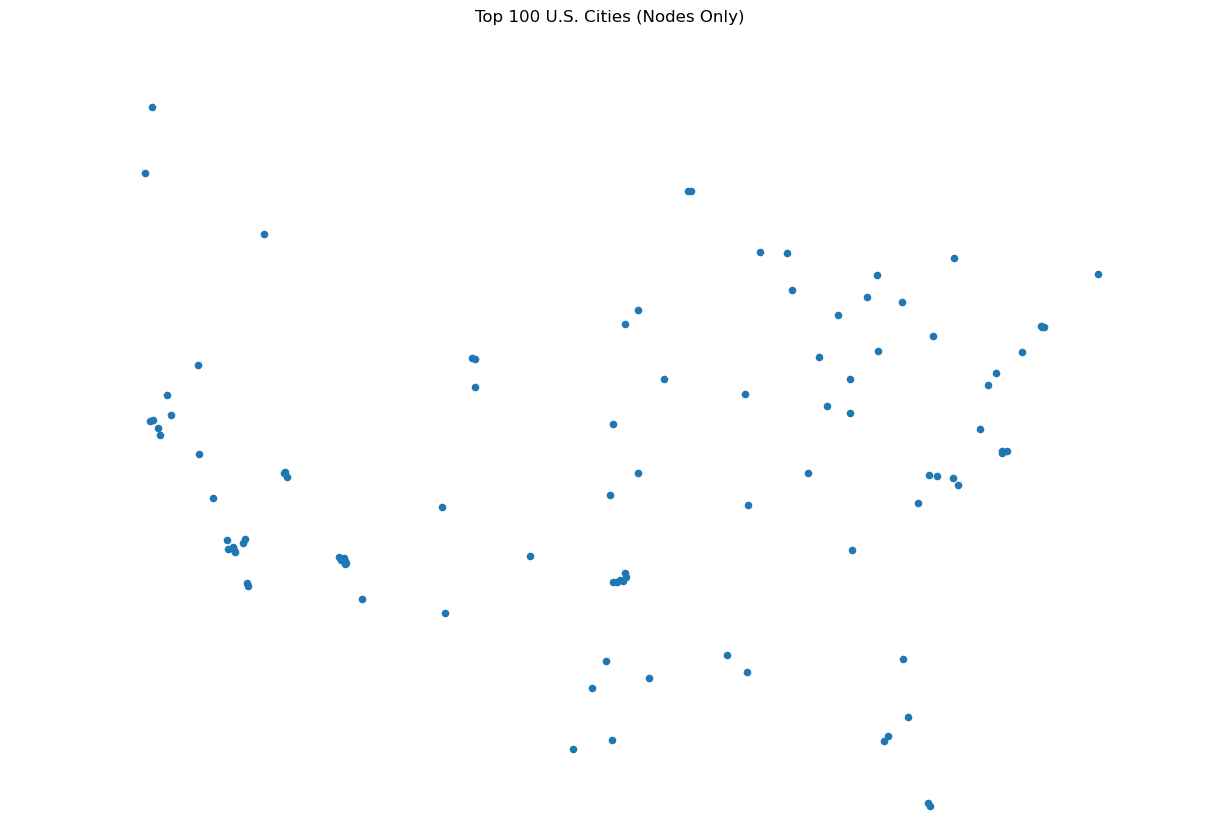

In [7]:
pos_vals = nx.get_node_attributes(top_100_graph, "pos")

plt.figure(figsize=(12,8))

nx.draw(top_100_graph, pos_vals, node_size=20, with_labels=False)

plt.title("Top 100 U.S. Cities (Nodes Only)")
plt.xlim(-130, -65)
plt.ylim(25, 50)

plt.show()